<a href="https://colab.research.google.com/github/Mahaselvi/amazon-fine-foods-sentiment/blob/main/Amazon_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon fine food reviews - Sentiment analysis

In [ ]:
#importing the dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS
import re
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/datasets/amazon_reviews/Reviews.csv")

## Data-Preprocessing

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
#checking for null values in the dataset
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
#dropping the features that are not necessary
df=df.drop(columns=['Id','UserId','ProfileName','HelpfulnessNumerator','HelpfulnessDenominator','Time'])

In [ ]:
#checking duplicate values in the Text and Summary features
df[['Text','Summary']].duplicated().sum()

np.int64(173484)

In [ ]:
#only the first occurence of the rows are kept
df=df.drop_duplicates(subset=['Text','Summary'],keep='first')

In [ ]:
df.head()

,ProductId,Score,Summary,Text
0,B001E4KFG0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,2,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,5,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

(394970, 4)

### Mapping scores to sentiment
- 1-2 = 0
-    3      = 1
- 4-5 = 2


In [ ]:
def map_sentiment(score):
    if(score<=2):
        return 0
    elif score==3:
        return 1
    else:
        return 2
df['Sentiment']=df['Score'].apply(map_sentiment)

In [ ]:
df.isnull().sum()

,0
ProductId,0
Score,0
Summary,3
Text,0
Sentiment,0


In [ ]:
df['Summary']=df['Summary'].fillna('')

In [ ]:
df.isnull().sum()

,0
ProductId,0
Score,0
Summary,0
Text,0
Sentiment,0


In [ ]:
df['combined_text']=df['Summary']+' '+df['Text']

In [ ]:
#removing the html entities
def clean_text(text):
    text = re.sub(r'&\w+;', ' ', text)      # HTML entities like &nbsp; &amp; &quot;
    text = re.sub(r'<.*?>', ' ', text)       # HTML tags like <br>, <a href=...>
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # strip digits/special symbols, keep letters
    text = re.sub(r'\s+', ' ', text).strip() # collapse extra whitespace
    return text
df['combined_text']=df['combined_text'].apply(clean_text)

In [ ]:
df=df.drop(columns=["Summary","Text","Score"])

In [ ]:
df.head()

,ProductId,Sentiment,combined_text
0,B001E4KFG0,2,Good Quality Dog Food I have bought several of...
1,B00813GRG4,0,Not as Advertised Product arrived labeled as J...
2,B000LQOCH0,2,Delight says it all This is a confection that ...
3,B000UA0QIQ,0,Cough Medicine If you are looking for the secr...
4,B006K2ZZ7K,2,Great taffy Great taffy at a great price There...


In [ ]:
#removing the negation words from the stop words
negation_words={'not', 'no', 'nor', 'never', 'none', 'nothing', 'nowhere',
                   'neither', "n't", 'cannot', "don't", "doesn't", "didn't",
                   "won't", "wouldn't", "can't", "couldn't", "shouldn't",
                   "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't"}
#adding the domain words into the custom_words
domain_words={'amazon','product','item','br','href'}
custom_words=ENGLISH_STOP_WORDS-(negation_words)| domain_words

## GroupShuffleSplit to slice the data for base learner, meta learner, and for the final test

In [ ]:
#GroupShuffleSplit is used to prevent reviews of same product end up in both train and test data, which may cause data leakage
#Split 1: Taking out the final 20% test data
gss1=GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
temp_idx,test_idx=next(gss1.split(df,groups=df['ProductId']))
df_temp=df.iloc[temp_idx].reset_index(drop=True)
df_test=df.iloc[test_idx].reset_index(drop=True)

In [ ]:
#Split 2: Dividing the 80% chunk into 60% for base learners and 20% for Meta learner
gss2=GroupShuffleSplit(n_splits=1,test_size=0.25,random_state=42)
base_idx,meta_idx=next(gss2.split(df_temp,groups=df_temp['ProductId']))
df_base=df_temp.iloc[base_idx].reset_index(drop=True)
df_meta=df_temp.iloc[meta_idx].reset_index(drop=True)

In [ ]:
#Slicing into x and y
x_base=df_base['combined_text']
y_base=df_base['Sentiment']

x_meta=df_meta['combined_text']
y_meta=df_meta['Sentiment']

x_test=df_test['combined_text']
y_test=df_test['Sentiment']

In [ ]:
print(f"Base Learner features: {x_base.shape[0]} rows")
print(f"Meta Learner features: {x_meta.shape[0]} rows")
print(f"Final Test features: {x_test.shape[0]} rows")

Base Learner features: 241357 rows
Meta Learner features: 76970 rows
Final Test features: 76643 rows


## Feature extraction

In [ ]:
#Feature extraction using td-idf vectorizer
feature_extraction=TfidfVectorizer(min_df=20,max_features=15000,stop_words=list(custom_words),lowercase=True,ngram_range=(1,2))
x_base_tfidf=feature_extraction.fit_transform(x_base)
x_meta_tfidf=feature_extraction.transform(x_meta)
x_test_tfidf=feature_extraction.transform(x_test)

In [ ]:
chunk_size=x_base_tfidf.shape[0]//6
print(chunk_size)

40226


## Splitting the chunks for the base learners

In [ ]:
# Chunk 1 - Logistic Regression
x_chunk1=x_base_tfidf[:chunk_size]
y_chunk1=y_base[:chunk_size]
# Chunk 2 - SDG
x_chunk2=x_base_tfidf[chunk_size:chunk_size*2]
y_chunk2=y_base[chunk_size:chunk_size*2]
# Chunk 3 - Random Forest
x_chunk3=x_base_tfidf[chunk_size*2:chunk_size*3]
y_chunk3=y_base[chunk_size*2:chunk_size*3]
# Chunk 4 - Linear SVC
x_chunk4=x_base_tfidf[chunk_size*3:chunk_size*4]
y_chunk4=y_base[chunk_size*3:chunk_size*4]
# Chunk 5 - Naive Bayes
x_chunk5=x_base_tfidf[chunk_size*4:chunk_size*5]
y_chunk5=y_base[chunk_size*4:chunk_size*5]
# Chunk 6 - XGBoost
x_chunk6=x_base_tfidf[chunk_size*5:]
y_chunk6=y_base[chunk_size*5:]

## Creating the base learner baselines

### Logistic Regression

In [ ]:
lr=LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(x_chunk1,y_chunk1)
#Predicting the meta chunk
y_pred_lr=lr.predict(x_meta_tfidf)
print("Logistic Regression Baseline: ")
print(classification_report(y_meta,y_pred_lr))

Logistic Regression Baseline: 
              precision    recall  f1-score   support

           0       0.65      0.77      0.70     11480
           1       0.29      0.48      0.36      5693
           2       0.96      0.87      0.91     59797

    accuracy                           0.83     76970
   macro avg       0.63      0.71      0.66     76970
weighted avg       0.87      0.83      0.84     76970



### SDG Classifier

In [ ]:
sgd=SGDClassifier(class_weight='balanced',random_state=42)
sgd.fit(x_chunk2,y_chunk2)
#predict on the meta chunk
y_pred_sgd=sgd.predict(x_meta_tfidf)
print("SDG Classifier Baseline: ")
print(classification_report(y_meta,y_pred_sgd))

SDG Classifier Baseline: 
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     11480
           1       0.41      0.32      0.36      5693
           2       0.93      0.94      0.94     59797

    accuracy                           0.87     76970
   macro avg       0.69      0.67      0.68     76970
weighted avg       0.86      0.87      0.86     76970



## Random forest

In [ ]:
rf=RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(x_chunk3,y_chunk3)
#predicting on the meta chunk
y_pred_rf=rf.predict(x_meta_tfidf)
print("Random Forest Baseline:\n ",classification_report(y_meta,y_pred_rf))

Random Forest Baseline:
                precision    recall  f1-score   support

           0       0.84      0.41      0.55     11480
           1       0.68      0.03      0.07      5693
           2       0.84      0.99      0.91     59797

    accuracy                           0.84     76970
   macro avg       0.79      0.48      0.51     76970
weighted avg       0.83      0.84      0.79     76970



## Linear SVC

In [ ]:
svc=LinearSVC(class_weight='balanced',random_state=42)
svc.fit(x_chunk4,y_chunk4)
#predict on the meta chunk
y_pred_svc=svc.predict(x_meta_tfidf)
print("LinearSVC Baseline:\n",classification_report(y_meta,y_pred_svc))

LinearSVC Baseline:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72     11480
           1       0.34      0.32      0.33      5693
           2       0.93      0.93      0.93     59797

    accuracy                           0.86     76970
   macro avg       0.66      0.66      0.66     76970
weighted avg       0.85      0.86      0.86     76970



## Naive Bayes

In [ ]:
nb=MultinomialNB()
nb.fit(x_chunk5,y_chunk5)
#predicting on the meta chunk
y_pred_nb=nb.predict(x_meta_tfidf)
print("Naive Bayes Baseline:\n",classification_report(y_meta,y_pred_nb))

Naive Bayes Baseline:
               precision    recall  f1-score   support

           0       0.83      0.38      0.52     11480
           1       0.66      0.01      0.01      5693
           2       0.83      0.99      0.90     59797

    accuracy                           0.83     76970
   macro avg       0.77      0.46      0.48     76970
weighted avg       0.82      0.83      0.78     76970



## XGBoost

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
weights=compute_sample_weight(class_weight='balanced',y=y_chunk6)
xgb=XGBClassifier(random_state=42,objective="multi:softmax",num_class=3)
xgb.fit(x_chunk6,y_chunk6,sample_weight=weights)
#predict on the meta chunk
y_pred_xgb=xgb.predict(x_meta_tfidf)
print("XGBoost Baseline:\n",classification_report(y_meta,y_pred_xgb))

XGBoost Baseline:
               precision    recall  f1-score   support

           0       0.61      0.74      0.67     11480
           1       0.27      0.48      0.35      5693
           2       0.95      0.84      0.89     59797

    accuracy                           0.80     76970
   macro avg       0.61      0.69      0.64     76970
weighted avg       0.85      0.80      0.82     76970



## Meta Learner

In [ ]:
#Packing the base models
base_models=[
    ('lr',lr),
    ('sgd',sgd),
    ('rf',rf),
    ('svc',svc),
    ('nb',nb),
    ('xgb',xgb)
]

### RandomizedSearchCV for the meta learner

In [ ]:
param_distributions={'C':[0.001,0.01,0.1,1,10,100,1000]}
custom_weights={0:2.0,1:4.0,2:1.0}
meta_search=RandomizedSearchCV(estimator=LogisticRegression(max_iter=1000,class_weight=custom_weights,random_state=42),
                               param_distributions=param_distributions,
                               n_iter=6,
                               cv=3,scoring='f1_macro',
                               random_state=42,
                               n_jobs=-1)
#stacking
stack_clf=StackingClassifier(estimators=base_models,final_estimator=meta_search,cv='prefit')
stack_clf.fit(x_meta_tfidf,y_meta)
print(f"Best Meta Learner parameters: {stack_clf.final_estimator_.best_params_}")

Best Meta Learner parameters: {'C': 10}


## Final Test

In [ ]:
final_predictions=stack_clf.predict(x_test_tfidf)
print(f"Final Stacking Ensemble Report:\n {classification_report(y_test,final_predictions)}")

Final Stacking Ensemble Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.75     11489
           1       0.36      0.52      0.42      5793
           2       0.95      0.92      0.93     59361

    accuracy                           0.86     76643
   macro avg       0.70      0.72      0.70     76643
weighted avg       0.88      0.86      0.87     76643



## Results visualization

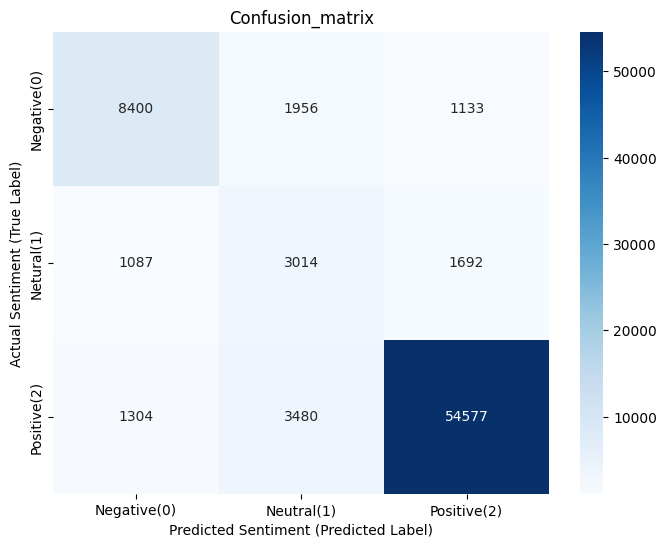

In [ ]:
cm=confusion_matrix(y_test,final_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Negative(0)','Neutral(1)','Positive(2)'],
            yticklabels=['Negative(0)','Netural(1)','Positive(2)']
            )
plt.title("Confusion_matrix")
plt.ylabel('Actual Sentiment (True Label)')
plt.xlabel('Predicted Sentiment (Predicted Label)')
plt.show()